# **CC6204 - Deep Learning**

## **Partes 1-4. Multi-Layer Perceptron para predicción de riesgo de diabetes en etapas tempranas**

En esta tarea vas a desarrollar un modelo de aprendizaje que sea capaz de  determinar si una persona tiene riesgo de paceder diabetes en un futuro. Los datos han sido coleccionados a través de encuestas a pacientes en el Sylhet Diabetes Hospital en Bangladesh. Los datos han sido curados y verificados por profesionales de la salud, por lo que son confiables para crear un modelo de aprendizaje.

Primero vamos a importar los paquetes necesarios para trabajar en estos datos.

In [1]:
import pathlib
import pandas as pd
import numpy as np

# visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.io as pio

sns.set_theme(style="dark")
pio.templates.default = "seaborn"

## **Descarga de archivo de datos**
Los datos están disponibles en un archivo CSV que contiene 520 muestras de 17 atributos. Los atributos son:

*   Age: numérico
*   Género: \[Male, Female\]
*   Polyuria
*   Polydipsia
*   sudden weight loss
*   weakness
*   Polyphagia
*   Genital thrush
*   visual blurring
*   Itching
*   Irritability
*   delayed healing
*   partial paresis
*   muscle stiffness
*   Alopecia
*   Obesity
*   Class: \[Positive, Negative\]

Todos los atributos descritos sin valores tienen el conjunto \[Yes, No\].

En la siguiente celda de código, descargamos el archivo y lo leemos con Pandas. Finalmente, visualizamos algunos datos del conjunto.



In [2]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00529/diabetes_data_upload.csv
dataset_path = 'diabetes_data_upload.csv'

--2025-09-12 16:54:09--  https://archive.ics.uci.edu/ml/machine-learning-databases/00529/diabetes_data_upload.csv
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘diabetes_data_upload.csv.2’

diabetes_data_uploa     [ <=>                ]  33.87K   205KB/s    in 0.2s    

2025-09-12 16:54:10 (205 KB/s) - ‘diabetes_data_upload.csv.2’ saved [34682]



In [3]:
import csv

with open('diabetes_data_upload.csv') as inp, open('temp.csv', 'w') as out:
    reader = csv.reader(inp)
    writer = csv.writer(out, delimiter=',')
    #No need to use `insert(), `append()` simply use `+` to concatenate two lists.
    writer.writerow(['ID'] + next(reader))
    #Iterate over enumerate object of reader and pass the starting index as 1.
    writer.writerows([i] + row for i, row in enumerate(reader, 1))

In [4]:
column_names = ['Age','Gender','Polyuria','Polydipsia','sudden weight loss',
                'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring','Itching', 'Irritability', 'delayed healing',
                'partial paresis', 'muscle stiffness', 'Alopecia', 'Obesity', 'class']
raw_dataset = pd.read_csv(dataset_path, names=column_names,
                      na_values = "?", comment='\t',
                      sep=",", skipinitialspace=True, header=1)

dataset = raw_dataset.copy()
dataset.head()

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
1,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
2,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
3,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive
4,55,Male,Yes,Yes,No,Yes,Yes,No,Yes,Yes,No,Yes,No,Yes,Yes,Yes,Positive


# **Pre-procesamiento del conjunto de datos**
El conjunto de datos es variado. El atributo "Age" es el único atributo numérico. Todos los demás atributos son nominales. Para procesar los datos nominales en una red neuronal, es mejor convertirlos a una representación numérica. En el siguiente ejemplo transformamos el atributo "Gender" con valores nominales "Female" y "Male" a valores 1.0 y 0.0, respectivamente.

Del mismo modo, cambiamos los valores nominales de todos los atributos a valores 0.0 y 1.0.

In [5]:
gender = dataset.pop('Gender')
dataset['gender'] = (gender == 'Female')*1.0

column_class = dataset.pop('class')
dataset['class'] = (column_class=='Positive')*1.0

for column in column_names:
  if column not in ['Gender', 'class', 'Age']:
    column_class = dataset.pop(column)
    dataset[column] = (column_class=='Yes')*1.0

# Prueba mostrando parte de la data para ver si tu conversión se hizo correctamente
dataset.tail()

,Age,gender,class,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity
514,39,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
515,48,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0
516,58,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
517,32,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
518,42,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Ahora normalizamos el atributo "Age" y dividimos la data en conjunto de entrenamiento y conjunto de test. Esta división es siempre necesaria para poder probar si tu modelo de aprendizaje ha aprendido a generalizar con datos que no pertenecen al conjunto de entrenamiento.

In [6]:
max_age = dataset["Age"].max()
dataset["Age"] = dataset["Age"] / max_age
dataset.tail()


#80% de datos para train y 20% de datos para test
train_dataset = dataset.sample(frac=0.8,random_state=0)
test_dataset = dataset.drop(train_dataset.index)

train_labels = train_dataset.pop('class')
test_labels = test_dataset.pop('class')

In [7]:
#Convertimos todo a arrays Numpy
X_train = train_dataset.to_numpy()
X_test = test_dataset.to_numpy()

Y_train = train_labels.to_numpy()
Y_test = test_labels.to_numpy()

Y_train = Y_train[:,None]
Y_test = Y_test[:,None]

print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(415, 16)
(415, 1)
(104, 16)
(104, 1)


# **Parte 1**
Diseña y entrena un perceptrón multicapa con la data de arriba. Intenta que tu modelo alcance el mayor accuracy de test posible (ojalá por encima del 93%). Para este primer experimento puedes usar la implementación de MLP vista en clase (basada en Numpy) ó puedes usar algún framework como Tensorflow o Pytorch si es que deseas. Hay que tener en cuenta algunas consideraciones para este primer experimento:



*   Usar gradiente descendiente estocástico con un tamaño de mini-batch de 20.
*   Usar learning rate de 0.01.
*  Los mini-batches NO se generan de manera aleatoria.

Graficar la función de loss con respecto a las épocas.

## Librerías

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 1234

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

## Dataset

In [9]:
# Convertir los datos numpy a tensores de PyTorch
X_train_torch = torch.tensor(X_train, dtype=torch.float32)
Y_train_torch = torch.tensor(Y_train, dtype=torch.float32)
X_test_torch = torch.tensor(X_test, dtype=torch.float32)
Y_test_torch = torch.tensor(Y_test, dtype=torch.float32)

batch_size = 20

# Dataset y DataLoader (sin shuffle para batches NO aleatorios)
train_dataset = TensorDataset(X_train_torch, Y_train_torch)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_dataset = TensorDataset(X_test_torch, Y_test_torch)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## Multilayer Perceptron

In [10]:
# Definir el modelo MLP en PyTorch
class MLP(nn.Module):
	def __init__(self, input_size, hidden_sizes, output_size, dropout_rate=0):
		super(MLP, self).__init__()

		# Input layer
		self.fc1 = nn.Linear(input_size, hidden_sizes[0])

		# Hidden layers, we use the pytorch equivalent of lists to have each hidden layer as part of the model (parameter)
		self.hidden_layers = nn.ModuleList([
				nn.Linear(hidden_sizes[i], hidden_sizes[i+1])
				for i in range(len(hidden_sizes)-1)
		])

		# Output layer
		self.fc_out = nn.Linear(hidden_sizes[-1], output_size)

		# Dropout rate for nns (we'll set it to 0 since it's optional)
		self.dropout_rate = dropout_rate

	def forward(self, x):
		# Input layer
		# ReLU as our activation function for the hidden layers
		x = F.relu(self.fc1(x))
		x = F.dropout(x, p=self.dropout_rate, training=self.training)

		# Hidden layers
		for hidden in self.hidden_layers:
			x = F.relu(hidden(x))
			x = F.dropout(x, p=self.dropout_rate, training=self.training)

		# Output layer using Sigmoid as our activation function for binary classification
		x = torch.sigmoid(self.fc_out(x))
		return x

def calculate_accuracy(y_pred, y):
  # top_pred = y_pred.argmax(1, keepdim=True)   # Multi-class
  top_pred = torch.round(y_pred)								# Binary-class
  correct = top_pred.eq(y.view_as(top_pred)).sum()
  acc = correct.float()/y.shape[0]
  return acc

In [11]:
# Function to train the model
def train(model, iterator, optimizer, criterion, device):
	# Initialize epoch loss, accuracy and set model to train mode
	epoch_loss = 0
	epoch_acc = 0
	model.train()

	# Iterate over each batch
	for (x, y) in iterator:
		# Move data to device (GPU or CPU)
		x, y = x.to(device), y.float().to(device)

		# Clear gradients
		optimizer.zero_grad()

		# Feed the network with the batch and get the predictions
		y_pred = model(x)

		# Calculate loss and accuracy
		loss = criterion(y_pred, y.view(-1,1))  # reshape to [batch,1]
		loss.backward()
		acc = calculate_accuracy(y_pred, y.view(-1,1))

		# Update the weights
		optimizer.step()

		# Keep track of the loss and accuracy
		epoch_loss += loss.item() #* x.shape[0]
		epoch_acc += acc.item()

	# Return the average loss and accuracy for the epoch
	return epoch_loss / len(iterator), epoch_acc / len(iterator)

def evaluate(model, iterator, criterion, device):
	epoch_loss = 0
	epoch_acc = 0
	# Set the model to evaluation mode
	model.eval()

	# We don't need to calculate the gradients when evaluating
	with torch.no_grad():
		for (x, y) in iterator:
			x, y = x.to(device), y.float().to(device)

			y_pred = model(x)
			loss = criterion(y_pred, y.view(-1,1))
			acc = calculate_accuracy(y_pred, y.view(-1,1))

			epoch_loss += loss.item() #* x.shape[0]
			epoch_acc += acc.item()

	return epoch_loss / len(iterator), epoch_acc / len(iterator)

def train_model(model, train_loader, test_loader, optimizer, criterion, epochs, device, plot=True):
	# Save losses
	train_losses = []
	test_losses = []

	for epoch in range(epochs):
		train_loss, train_acc = train(model, train_loader, optimizer, criterion, device)
		test_loss, test_acc = evaluate(model, test_loader, criterion, device)
		train_losses.append(train_loss)
		test_losses.append(test_loss)

		print(f'Epoch: {epoch+1:02}')
		print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
		print(f'\t Test Loss: {test_loss:.3f} |  Test Acc: {test_acc*100:.2f}%')

	def _plot_losses(train_losses, test_losses):
		# Plotting the losses (using plotly)
		fig = go.Figure()
		fig.add_trace(go.Scatter(x=list(range(1, epochs+1)), y=train_losses, mode='lines+markers', name='Train Loss'))
		fig.add_trace(go.Scatter(x=list(range(1, epochs+1)), y=test_losses, mode='lines+markers', name='Test Loss'))

		fig.update_layout(
				title='Loss function over Epochs',
				xaxis_title='Epochs',
				yaxis_title='Loss',
		)
		fig.show()

		# Using seaborn
		# sns.lineplot(x=range(1, epochs+1), y=train_losses, label='Train Loss')
		# sns.lineplot(x=range(1, epochs+1), y=test_losses, label='Test Loss')
		# plt.xlabel('Epochs')
		# plt.ylabel('Loss')
		# plt.title('Loss function over Epochs')
		# plt.legend()
		# plt.grid(True)
		# plt.show()

	if plot:
		_plot_losses(train_losses, test_losses)

	return train_losses, test_losses

In [12]:
# MLP instantiation
input_size = X_train.shape[1]
hidden_sizes = [16, 4]
output_size = 1
mlp = MLP(input_size, hidden_sizes, output_size).to(device)

# Loss and optimizer
criterion = nn.BCELoss().to(device)
# optimizer = optim.Adam(mlp.parameters(), lr=0.01)
optimizer = optim.SGD(mlp.parameters(), lr=0.01)

epochs = 250

train_losses_batch20, test_losses_batch20 = train_model(mlp, train_loader, test_loader, optimizer, criterion, epochs, device)

Epoch: 01
	Train Loss: 0.668 | Train Acc: 61.35%
	 Test Loss: 0.655 |  Test Acc: 63.33%
Epoch: 02
	Train Loss: 0.665 | Train Acc: 61.35%
	 Test Loss: 0.653 |  Test Acc: 63.33%
Epoch: 03
	Train Loss: 0.663 | Train Acc: 61.35%
	 Test Loss: 0.650 |  Test Acc: 63.33%
Epoch: 04
	Train Loss: 0.661 | Train Acc: 61.35%
	 Test Loss: 0.647 |  Test Acc: 63.33%
Epoch: 05
	Train Loss: 0.658 | Train Acc: 61.35%
	 Test Loss: 0.644 |  Test Acc: 63.33%
Epoch: 06
	Train Loss: 0.655 | Train Acc: 61.35%
	 Test Loss: 0.641 |  Test Acc: 63.33%
Epoch: 07
	Train Loss: 0.652 | Train Acc: 61.35%
	 Test Loss: 0.638 |  Test Acc: 63.33%
Epoch: 08
	Train Loss: 0.650 | Train Acc: 61.35%
	 Test Loss: 0.635 |  Test Acc: 63.33%
Epoch: 09
	Train Loss: 0.647 | Train Acc: 61.35%
	 Test Loss: 0.631 |  Test Acc: 63.33%
Epoch: 10
	Train Loss: 0.643 | Train Acc: 61.35%
	 Test Loss: 0.628 |  Test Acc: 63.33%
Epoch: 11
	Train Loss: 0.640 | Train Acc: 61.35%
	 Test Loss: 0.624 |  Test Acc: 63.33%
Epoch: 12
	Train Loss: 0.636 | T

# **Parte 2**
Intenta cambiar el tamaño de los mini-batches. Como casos extremos usa m=1 (mini-batches de tamaño 1) y m=n(1 solo mini-batch con todos los datos). Qué resultados obtienes? Discute los resultados. (Hay que explicar el fenómeno observado, dando su opinión de porqué sucede).

Graficar la función de loss con respecto a las épocas y comparar con la función de loss de la Parte 1.

In [ ]:
# Case experiment with batch-size = 1
batch_size_1 = 1
train_loader_1 = DataLoader(train_dataset, batch_size=batch_size_1, shuffle=False)
test_loader_1 = DataLoader(test_dataset, batch_size=batch_size_1, shuffle=False)

mlp_1 = MLP(input_size, hidden_sizes, output_size).to(device)
# optimizer_1 = optim.Adam(mlp_1.parameters(), lr=0.01)
optimizer_1 = optim.SGD(mlp_1.parameters(), lr=0.01)

train_losses_batch1, test_losses_batch1 = train_model(mlp_1, train_loader_1, test_loader_1, optimizer_1, criterion, epochs, device)

Epoch: 01
	Train Loss: 0.584 | Train Acc: 62.41%
	 Test Loss: 0.504 |  Test Acc: 67.31%
Epoch: 02
	Train Loss: 0.434 | Train Acc: 80.00%
	 Test Loss: 0.373 |  Test Acc: 88.46%
Epoch: 03
	Train Loss: 0.325 | Train Acc: 89.64%
	 Test Loss: 0.297 |  Test Acc: 94.23%
Epoch: 04
	Train Loss: 0.273 | Train Acc: 92.05%
	 Test Loss: 0.257 |  Test Acc: 94.23%
Epoch: 05
	Train Loss: 0.243 | Train Acc: 93.49%
	 Test Loss: 0.230 |  Test Acc: 94.23%
Epoch: 06
	Train Loss: 0.221 | Train Acc: 94.22%
	 Test Loss: 0.215 |  Test Acc: 94.23%
Epoch: 07
	Train Loss: 0.202 | Train Acc: 94.46%
	 Test Loss: 0.205 |  Test Acc: 94.23%
Epoch: 08
	Train Loss: 0.189 | Train Acc: 94.70%
	 Test Loss: 0.202 |  Test Acc: 93.27%
Epoch: 09
	Train Loss: 0.178 | Train Acc: 94.70%
	 Test Loss: 0.198 |  Test Acc: 93.27%
Epoch: 10
	Train Loss: 0.170 | Train Acc: 94.70%
	 Test Loss: 0.197 |  Test Acc: 92.31%
Epoch: 11
	Train Loss: 0.164 | Train Acc: 94.70%
	 Test Loss: 0.196 |  Test Acc: 92.31%
Epoch: 12
	Train Loss: 0.158 | T

In [ ]:
                                                                  # Case experiment with batch-size = len(train_dataset)
batch_size_full = len(train_dataset)
train_loader_full = DataLoader(train_dataset, batch_size=batch_size_full, shuffle=False)
test_loader_full = DataLoader(test_dataset, batch_size=batch_size_full, shuffle=False)

mlp_full = MLP(input_size, hidden_sizes, output_size).to(device)
# optimizer_full = optim.Adam(mlp_full.parameters(), lr=0.01)
optimizer_full = optim.SGD(mlp_full.parameters(), lr=0.01)

train_losses_batchfull, test_losses_batchfull = train_model(mlp_full, train_loader_full, test_loader_full, optimizer_full, criterion, epochs, device)

Epoch: 01
	Train Loss: 0.661 | Train Acc: 61.45%
	 Test Loss: 0.661 |  Test Acc: 61.54%
Epoch: 02
	Train Loss: 0.661 | Train Acc: 61.45%
	 Test Loss: 0.660 |  Test Acc: 61.54%
Epoch: 03
	Train Loss: 0.660 | Train Acc: 61.45%
	 Test Loss: 0.660 |  Test Acc: 61.54%
Epoch: 04
	Train Loss: 0.660 | Train Acc: 61.45%
	 Test Loss: 0.660 |  Test Acc: 61.54%
Epoch: 05
	Train Loss: 0.660 | Train Acc: 61.45%
	 Test Loss: 0.659 |  Test Acc: 61.54%
Epoch: 06
	Train Loss: 0.659 | Train Acc: 61.45%
	 Test Loss: 0.659 |  Test Acc: 61.54%
Epoch: 07
	Train Loss: 0.659 | Train Acc: 61.45%
	 Test Loss: 0.659 |  Test Acc: 61.54%
Epoch: 08
	Train Loss: 0.659 | Train Acc: 61.45%
	 Test Loss: 0.658 |  Test Acc: 61.54%
Epoch: 09
	Train Loss: 0.658 | Train Acc: 61.45%
	 Test Loss: 0.658 |  Test Acc: 61.54%
Epoch: 10
	Train Loss: 0.658 | Train Acc: 61.45%
	 Test Loss: 0.658 |  Test Acc: 61.54%
Epoch: 11
	Train Loss: 0.658 | Train Acc: 61.45%
	 Test Loss: 0.657 |  Test Acc: 61.54%
Epoch: 12
	Train Loss: 0.657 | T

In [ ]:
fig = go.Figure()

# Batch 20
fig.add_trace(go.Scatter(x=list(range(1, epochs+1)), y=train_losses_batch20,
    mode='lines+markers', name='Train Loss (batch=20)', line=dict(color="blue")))
fig.add_trace(go.Scatter(x=list(range(1, epochs+1)), y=test_losses_batch20,
    mode='lines+markers', name='Test Loss (batch=20)', line=dict(color="blue", dash="dot"), opacity=0.5))

# Batch 1
fig.add_trace(go.Scatter(x=list(range(1, epochs+1)), y=train_losses_batch1,
    mode='lines+markers', name='Train Loss (batch=1)', line=dict(color="green")))
fig.add_trace(go.Scatter(x=list(range(1, epochs+1)), y=test_losses_batch1,
    mode='lines+markers', name='Test Loss (batch=1)', line=dict(color="green", dash="dot"), opacity=0.5))

# Batch full
fig.add_trace(go.Scatter(x=list(range(1, epochs+1)), y=train_losses_batchfull,
    mode='lines+markers', name='Train Loss (batch=full)', line=dict(color="red")))
fig.add_trace(go.Scatter(x=list(range(1, epochs+1)), y=test_losses_batchfull,
    mode='lines+markers', name='Test Loss (batch=full)', line=dict(color="red", dash="dot"), opacity=0.5))

fig.update_layout(
    title='Loss function over Epochs (lr=0.01, shuffle=False)',
    xaxis_title='Epochs',
    yaxis_title='Loss'
)
fig.show()

Del gráfico se puede ver cómo las curvas rojas se quedan estancadas para la cantidad de épocas con las que se compara (su loss apenas disminuye) siendo el modelo con peor rendimiento por falta de más épocas, esto se debe por la cantidad tan baja de actualizaciones de los parámetros (los cálculos del gradiente son más exactos al considerar todo el dataset pero por ello se actualizan una sola vez por época), por otro lado para las curvas azules se tiene una minimización de la loss más constante, es decir los parámetros se actualizan más seguido en comparación al batch-size previo, esto porque se considera una cantidad mediana de datos para actualizar los mismos en una misma época y finalmente las curvas verdes que son más volatiles al considerar un solo dato por actualización se overfittean en pocas épocas por lo mismo (converge más rápido)

# **Parte 3**
Intenta cambiar el learning rate. Como casos extremos usa lr = 0.5 y lr = 0.000001. Qué resultados obtienes? Discute los resultados. (Hay que explicar el fenómeno observado, dando su opinión de porqué sucede).

Graficar la función de loss con respecto a las épocas y comparar con la función de loss de la Parte 1.

In [13]:
# Case experiment with learning rate = 0.5
lr_dot5 = 0.5
train_loader_lr_dot5 = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_loader_lr_dot5 = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

mlp_lr_dot5 = MLP(input_size, hidden_sizes, output_size).to(device)
optimizer_lr_dot5 = optim.SGD(mlp_lr_dot5.parameters(), lr=lr_dot5)

train_losses_lr_dot5, test_losses_lr_dot5 = train_model(mlp_lr_dot5, train_loader_lr_dot5, test_loader_lr_dot5, optimizer_lr_dot5, criterion, epochs, device)

Epoch: 01
	Train Loss: 0.493 | Train Acc: 71.75%
	 Test Loss: 0.406 |  Test Acc: 83.33%
Epoch: 02
	Train Loss: 0.283 | Train Acc: 90.32%
	 Test Loss: 0.360 |  Test Acc: 80.00%
Epoch: 03
	Train Loss: 0.222 | Train Acc: 93.25%
	 Test Loss: 0.309 |  Test Acc: 84.17%
Epoch: 04
	Train Loss: 0.191 | Train Acc: 94.21%
	 Test Loss: 0.293 |  Test Acc: 85.83%
Epoch: 05
	Train Loss: 0.174 | Train Acc: 94.44%
	 Test Loss: 0.272 |  Test Acc: 89.17%
Epoch: 06
	Train Loss: 0.163 | Train Acc: 94.92%
	 Test Loss: 0.252 |  Test Acc: 90.00%
Epoch: 07
	Train Loss: 0.154 | Train Acc: 95.63%
	 Test Loss: 0.226 |  Test Acc: 91.67%
Epoch: 08
	Train Loss: 0.143 | Train Acc: 96.43%
	 Test Loss: 0.179 |  Test Acc: 94.17%
Epoch: 09
	Train Loss: 0.137 | Train Acc: 96.43%
	 Test Loss: 0.187 |  Test Acc: 93.33%
Epoch: 10
	Train Loss: 0.131 | Train Acc: 96.67%
	 Test Loss: 0.179 |  Test Acc: 93.33%
Epoch: 11
	Train Loss: 0.123 | Train Acc: 96.67%
	 Test Loss: 0.168 |  Test Acc: 95.00%
Epoch: 12
	Train Loss: 0.114 | T

In [14]:
# Case experiment with learning rate = 0.000001
lr_dot000001 = 0.000001
train_loader_lr_dot000001 = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_loader_lr_dot000001 = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

mlp_lr_dot000001 = MLP(input_size, hidden_sizes, output_size).to(device)
optimizer_lr_dot000001 = optim.SGD(mlp_lr_dot000001.parameters(), lr=lr_dot000001)

train_losses_lr_dot000001, test_losses_lr_dot000001 = train_model(mlp_lr_dot000001, train_loader_lr_dot000001, test_loader_lr_dot000001, optimizer_lr_dot000001, criterion, epochs, device)

Epoch: 01
	Train Loss: 0.661 | Train Acc: 61.35%
	 Test Loss: 0.658 |  Test Acc: 63.33%
Epoch: 02
	Train Loss: 0.661 | Train Acc: 61.35%
	 Test Loss: 0.658 |  Test Acc: 63.33%
Epoch: 03
	Train Loss: 0.661 | Train Acc: 61.35%
	 Test Loss: 0.658 |  Test Acc: 63.33%
Epoch: 04
	Train Loss: 0.661 | Train Acc: 61.35%
	 Test Loss: 0.658 |  Test Acc: 63.33%
Epoch: 05
	Train Loss: 0.661 | Train Acc: 61.35%
	 Test Loss: 0.658 |  Test Acc: 63.33%
Epoch: 06
	Train Loss: 0.661 | Train Acc: 61.35%
	 Test Loss: 0.658 |  Test Acc: 63.33%
Epoch: 07
	Train Loss: 0.661 | Train Acc: 61.35%
	 Test Loss: 0.658 |  Test Acc: 63.33%
Epoch: 08
	Train Loss: 0.661 | Train Acc: 61.35%
	 Test Loss: 0.658 |  Test Acc: 63.33%
Epoch: 09
	Train Loss: 0.661 | Train Acc: 61.35%
	 Test Loss: 0.658 |  Test Acc: 63.33%
Epoch: 10
	Train Loss: 0.661 | Train Acc: 61.35%
	 Test Loss: 0.658 |  Test Acc: 63.33%
Epoch: 11
	Train Loss: 0.661 | Train Acc: 61.35%
	 Test Loss: 0.658 |  Test Acc: 63.33%
Epoch: 12
	Train Loss: 0.661 | T

In [15]:
fig = go.Figure()

# Batch 20, learning rate 0.01
fig.add_trace(go.Scatter(x=list(range(1, epochs+1)), y=train_losses_batch20,
    mode='lines+markers', name='Train Loss (lr=0.01)', line=dict(color="blue")))
fig.add_trace(go.Scatter(x=list(range(1, epochs+1)), y=test_losses_batch20,
    mode='lines+markers', name='Test Loss (lr=0.01)', line=dict(color="blue", dash="dot"), opacity=0.5))

# learning rate 0.5
fig.add_trace(go.Scatter(x=list(range(1, epochs+1)), y=train_losses_lr_dot5,
    mode='lines+markers', name='Train Loss (lr=0.5)', line=dict(color="green")))
fig.add_trace(go.Scatter(x=list(range(1, epochs+1)), y=test_losses_lr_dot5,
    mode='lines+markers', name='Test Loss (lr=0.5)', line=dict(color="green", dash="dot"), opacity=0.5))

# learning rate 0.000001
fig.add_trace(go.Scatter(x=list(range(1, epochs+1)), y=train_losses_lr_dot000001,
    mode='lines+markers', name='Train Loss (lr=0.000001)', line=dict(color="red")))
fig.add_trace(go.Scatter(x=list(range(1, epochs+1)), y=test_losses_lr_dot000001,
    mode='lines+markers', name='Test Loss (lr=0.000001)', line=dict(color="red", dash="dot"), opacity=0.5))

fig.update_layout(
    title='Loss function over Epochs (batch=20, shuffle=False)',
    xaxis_title='Epochs',
    yaxis_title='Loss'
)
fig.show()

La curva roja (lr muy bajo) converge extremadamente lento, ya que los pasos de actualización son demasiado pequeños y el modelo prácticamente no aprende. Las curvas azules (lr intermedio) muestran una convergencia estable y más rápida, aunque con inicio de overfitting tras ~150 épocas. En cambio, las curvas verdes (lr alto) descienden velozmente pero de forma inestable, presentando picos al “pasarse de largo” del mínimo

# **Parte 4**
Implementar el algoritmo de gradiente descendente estocástico de manera que los mini-batches se generen de manera aleatoria antes de cada época. Qué resultados obtienes? Discute los resultados. (Hay que explicar el fenómeno observado, dando su opinión de porqué sucede).

Graficar la función de loss con respecto a las épocas y comparar con la función de loss de la Parte 1.

In [ ]:
# Case experiment with shuffle = True
train_loader_shuffe = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader_shuffle = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

mlp_shuffle = MLP(input_size, hidden_sizes, output_size).to(device)
optimizer_shuffle = optim.SGD(mlp_shuffle.parameters(), lr=0.01)

train_losses_shuffle, test_losses_shuffle = train_model(mlp_shuffle, train_loader_shuffe, test_loader_shuffle, optimizer_shuffle, criterion, epochs, device)

Epoch: 01
	Train Loss: 0.656 | Train Acc: 61.59%
	 Test Loss: 0.646 |  Test Acc: 63.33%
Epoch: 02
	Train Loss: 0.654 | Train Acc: 61.35%
	 Test Loss: 0.647 |  Test Acc: 63.33%
Epoch: 03
	Train Loss: 0.651 | Train Acc: 61.43%
	 Test Loss: 0.647 |  Test Acc: 63.33%
Epoch: 04
	Train Loss: 0.649 | Train Acc: 61.43%
	 Test Loss: 0.642 |  Test Acc: 63.33%
Epoch: 05
	Train Loss: 0.646 | Train Acc: 61.35%
	 Test Loss: 0.658 |  Test Acc: 60.00%
Epoch: 06
	Train Loss: 0.643 | Train Acc: 61.43%
	 Test Loss: 0.671 |  Test Acc: 56.67%
Epoch: 07
	Train Loss: 0.640 | Train Acc: 61.43%
	 Test Loss: 0.657 |  Test Acc: 60.00%
Epoch: 08
	Train Loss: 0.639 | Train Acc: 61.19%
	 Test Loss: 0.630 |  Test Acc: 63.33%
Epoch: 09
	Train Loss: 0.637 | Train Acc: 61.03%
	 Test Loss: 0.634 |  Test Acc: 63.33%
Epoch: 10
	Train Loss: 0.631 | Train Acc: 61.43%
	 Test Loss: 0.625 |  Test Acc: 63.33%
Epoch: 11
	Train Loss: 0.628 | Train Acc: 61.35%
	 Test Loss: 0.599 |  Test Acc: 66.67%
Epoch: 12
	Train Loss: 0.622 | T

In [ ]:
fig = go.Figure()

# Batch 20, learning rate 0.01, shuffle False
fig.add_trace(go.Scatter(x=list(range(1, epochs+1)), y=train_losses_batch20,
    mode='lines+markers', name='Train Loss (shuffle=False)', line=dict(color="blue")))
fig.add_trace(go.Scatter(x=list(range(1, epochs+1)), y=test_losses_batch20,
    mode='lines+markers', name='Test Loss (shuffle=False)', line=dict(color="blue", dash="dot"), opacity=0.5))

# shuffle True
fig.add_trace(go.Scatter(x=list(range(1, epochs+1)), y=train_losses_shuffle,
    mode='lines+markers', name='Train Loss (shuffle=True)', line=dict(color="green")))
fig.add_trace(go.Scatter(x=list(range(1, epochs+1)), y=test_losses_shuffle,
    mode='lines+markers', name='Test Loss (shuffle=True)', line=dict(color="green", dash="dot"), opacity=0.5))

fig.update_layout(
    title='Loss function over Epochs (batch=20, lr=0.01)',
    xaxis_title='Epochs',
    yaxis_title='Loss'
)
fig.show()

Podemos ver que el comportamiento para las curvas azules es más suave mientras que el de las curvas verdes es errático, esto pasa dado que los mini batches que se usan para calcular los gradientes van cambiando de época en época (destacar que el loss promedio no se ve muy afectado con el ruido del azar)

# **Parte 5: Visualización de Loss Landscape**

En Deep-Learning, es común analizar la evolución de la Loss mediante visualizacion del $Loss~Landscape$ durante el entrenamiento (vease https://arxiv.org/pdf/1712.09913). En esta parte usted debe realizar al menos dos comparaciones de entrenamientos mediante la visualización de la $Loss~Landscape$.

### Loss Landscape

La visualización del **loss landscape** permite analizar cómo varía la función de pérdida en torno a los parámetros de un modelo entrenado.  

Consideremos la función de pérdida $L$ como una función que depende de los parámetros del modelo $\theta$. El objetivo es generar una **visualización 2D** del landscape de $L$.  

Dado que $\theta$ es un vector de dimensión $N \gg 2$, es imposible graficar la loss en función de este vector directamente. Para resolver este problema:  

- Se seleccionan **dos direcciones representativas** de la variación de los parámetros ($\delta$ y $\eta$). Luego podemos parametrizar la loss landscape mediante dos escalares de la siguiente forma:

  $
L(\alpha,\beta) = \mathcal{L}(\theta_c + \alpha \cdot \delta + \beta \cdot \eta)
$

  donde $\alpha,\beta$ son escalares y $\theta_c$ corresponde a los parámetros finales del modelo (última época).  

- Con esta función, es posible graficar la loss en funcion de los escalares en un plano 2D.  


---

## Procedimiento

**Usted debera utilizar las funciones proporcionadas en el material de la tarea para la ejecución de los siguientes pasos. En esta parte de la tarea se espera que el foco sea analizar los resultados mas que implementar codigo.**

### 1. Entrenamiento y almacenamiento de pesos
- Entrene el modelo.  
- Guarde los pesos del modelo después de cada época. Posterior al entrenamiento, usted tendrá una lista de state_dicts del modelo $\{W_0, W_1, \dots, W_T\}$.  

---

### 2. Obtención de direcciones principales
- Considere cada conjunto de pesos como un vector en $\mathbb{R}^N$.  
- Aplique **Análisis de Componentes Principales (PCA)** a todos los pesos guardados.  
- Tome las **dos primeras componentes principales**:  
  - $\delta$: primera dirección de mayor varianza.  
  - $\eta$: segunda dirección de mayor varianza.  

---

### 3. Construcción del loss landscape
- Defina un rango para los parámetros escalares $\alpha, \beta \in [-k, k]$.  
- Evalúe la función de pérdida:  

$
L(\alpha, \beta) = \mathcal{L}(\theta_c + \alpha \cdot \delta + \beta \cdot \eta)
$

- Grafique el resultado como **mapa de calor** o **superficie 3D**.  

---

### 4. Visualización de la trayectoria de entrenamiento
Para mostrar el camino seguido por el modelo:  

- Para cada conjunto de pesos $W_i$, calcule su proyección en el plano $L(\alpha, \beta)$. Para ello usted puede resolver la ecuación:  

  $
W_i - W_c = \alpha \cdot \delta + \beta \cdot \eta
$

- Resolver esta ecuación usando metodos tradicionales no es directo, pues las matrices no son cuadradas. Para este caso, utilizaremos el metodo de **pseudo inversa de Moore-Penrose (https://en.wikipedia.org/wiki/Moore%E2%80%93Penrose_inverse)**.  
- Trace la trayectoria resultante sobre el loss landscape.  

---

✅ **Resultado esperado:**  
- Un gráfico del loss landscape en 2D para los dos casos de estudio.  
- La trayectoria del entrenamiento superpuesta en dicho espacio, mostrando cómo evolucionaron los parámetros hasta la convergencia.  


## Solución

A continuación, se presenta el flujo que deberá seguir para responder las preguntas de esta sección. Para esto, haga uso de las funciones que se encuentran en los archivos "model_utils.py" y "loss_landscape.py". Solo debe implementar dos funciones en el archivo "model_utils.py" (explicado mas adelante). Usted deberá realizar las siguientes dos comparaciones de loss landscape:

- Cambiando diferentes optimizadores (por ejemplo, SGD vs Adam).
- Cambiando funciones de activaciones (por ejemplo, Relu vs Gelu).

Adicionalmente, usted puede hacer cambios en el codigo ya implementado si considera que esto puede mejorar sus resultados y/o análisis. Fundamente sus decisiones.

### Dataset

In [ ]:
#Usaremos un dataset clasico como MNIST
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import copy
import numpy as np

torch.manual_seed(2003)
np.random.seed(2003)

device = "cuda:0"
batch_size = 64

transform = transforms.Compose([
    transforms.ToTensor(),   # Convert to tensor [0,1]
    transforms.Lambda(lambda x: x.view(-1))  # Flatten 28x28 -> 784
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.06MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.18MB/s]


### Modelo

Ahora, importamos un modelo Multi-Layer Perceptron y algunas funciones de utilidad para chequear una iniciación de parametros equivalente.

In [ ]:
import sys
sys.path.append('../')
from model_utils import *

In [ ]:
#ejemplo: sanity check para verificar que modelos inician con set de parametros equivalentes
model_sgd = MLP_ReLU()
torch.manual_seed(2003)
model_sgd.apply(init_weights)
model_adam = MLP_ReLU()
torch.manual_seed(2003)
model_adam.apply(init_weights)
print(models_are_equal(model_sgd,model_adam))

True


### Entrenamiento

In [ ]:
from model_utils import train_model, eval_mnist_fn

## Caso 1: Optimizadores

Realice una comparación del loss landscape considerando el entrenamiento de modelos con diferentes optimizadores.

In [ ]:
# Ejemplo: Entrenamiento de modelos con diferentes optimizadores
_, _, acc_sgd, w_history_sgd = train_model(model=model_sgd,
                                      train_loader=train_loader,
                                      test_loader=test_loader,
                                      optimizer_fn=optim.SGD,
                                      lr=0.001,
                                      criterion=nn.CrossEntropyLoss(),
                                      num_epochs=10,
                                      eval_fn=eval_mnist_fn,
                                      device=device)
_, _, acc_adam, w_history_adam = train_model(model=model_adam,
                                      train_loader=train_loader,
                                      test_loader=test_loader,
                                      optimizer_fn=optim.Adam,
                                      lr=0.001,
                                      criterion=nn.CrossEntropyLoss(),
                                      num_epochs=10,
                                      eval_fn=eval_mnist_fn,
                                      device=device)

Ahora debemos generar las visualizaciones, para ello utilice la función "compare_training_paths" en el archivo "loss_landscape_utils.py" adjunto en material docente de Ucursos. Si quiere mejorar la visualización, puede modificar el codigo.

In [ ]:
from loss_landscape_utils import compare_training_paths

doing PCA over training states over model...
creating Surface instance and calculating loss over landscape of model 1...
doing PCA over training states over model...
creating Surface instance and calculating loss over landscape of model 1...
Loss range: 0.0011 - 3.0000
Animation saved to comparison1.gif


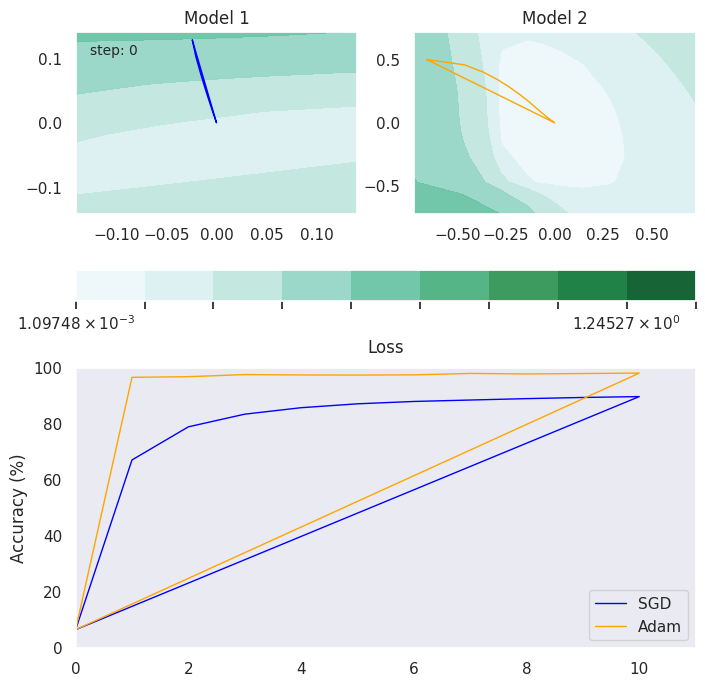

In [ ]:
#ejemplo de uso
compare_training_paths(model_1=model_sgd,
                       model_2=model_adam,
                       w_history_1=w_history_sgd,
                       w_history_2=w_history_adam,
                       acc_vals_1=acc_sgd,
                       acc_vals_2=acc_adam,
                       loader=test_loader,
                       eval_fn=eval_mnist_fn,
                       resolution=15,
                       levels=10,
                       loss_range=0.75,
                       criterion=None,
                       filename="comparison1.gif",
                       fps=5,
                       interval=50)

##

## Caso 2: Funciones de activación

Realice una comparación de la loss landscape para diferentes funciones de activación en los modelos. Utilice un desarrollo analogo al caso 1.

In [ ]:
model_relu = MLP_ReLU()
torch.manual_seed(2003)
model_relu.apply(init_weights)
model_sigmoid = MLP_Sigmoid()
torch.manual_seed(2003)
model_sigmoid.apply(init_weights)

MLP_Sigmoid(
  (dropout): Dropout(p=0, inplace=False)
  (layer_1): Linear(in_features=784, out_features=256, bias=True)
  (layer_2): Linear(in_features=256, out_features=128, bias=True)
  (layer_3): Linear(in_features=128, out_features=10, bias=True)
  (activation): Sigmoid()
)

In [ ]:
_, _, acc_relu, w_history_relu = train_model(model=model_relu,
                                      train_loader=train_loader,
                                      test_loader=test_loader,
                                      optimizer_fn=optim.SGD,
                                      lr=0.001,
                                      criterion=nn.CrossEntropyLoss(),
                                      num_epochs=10,
                                      eval_fn=eval_mnist_fn,
                                      device=device)
_, _, acc_sigmoid, w_history_sigmoid = train_model(model=model_sigmoid,
                                      train_loader=train_loader,
                                      test_loader=test_loader,
                                      optimizer_fn=optim.SGD,
                                      lr=0.001,
                                      criterion=nn.CrossEntropyLoss(),
                                      num_epochs=10,
                                      eval_fn=eval_mnist_fn,
                                      device=device)

doing PCA over training states over model...
creating Surface instance and calculating loss over landscape of model 1...
doing PCA over training states over model...
creating Surface instance and calculating loss over landscape of model 1...
Loss range: 0.0055 - 3.0000
Animation saved to comparison3.gif


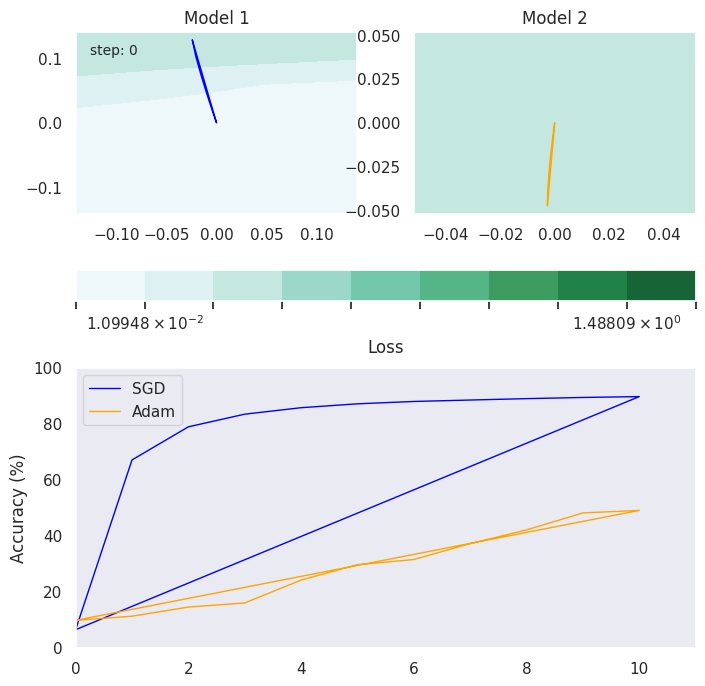

In [ ]:
compare_training_paths(model_1=model_relu,
                       model_2=model_sigmoid,
                       w_history_1=w_history_relu,
                       w_history_2=w_history_sigmoid,
                       acc_vals_1=acc_relu,
                       acc_vals_2=acc_sigmoid,
                       loader=test_loader,
                       eval_fn=eval_mnist_fn,
                       resolution=15,
                       levels=10,
                       loss_range=0.75,
                       criterion=None,
                       filename="comparison3.gif",
                       fps=5,
                       interval=50)

## **Preguntas:**

1) ¿Por qué no podemos visualizar directamente la pérdida en el espacio de todos los parámetros $\theta$?
- Puesto que no hay forma de graficar una función de tantas dimensiones ($\theta$ es un vector de $\mathbb{R}^N$ con $N \gg 2$ por lo que vive en un espacio de muchas dimensiones), por ello se debe usar PCA para hacerlo

2) ¿Cuales son las principales diferencias que nota en la visualización de loss landscape? ¿Qué significa si la trayectoria se mueve mucho alrededor del mínimo final?
- Que el algoritmo del descenso gradiente estocástico es bien lento en comparación a Adam, lo cual se puede ver en los gráficos de las 2 primeras componentes, donde los pasos son más cortos en SGD. Si se diese el caso de que la trayectoria oscilara mucho en el mínimo sería indicador de que el optimizador no logra estabilizarse (por culpa de un lr muy grande o un mínimo muy estrecho) dificultando la convergencia

3) ¿Qué podría pasar si tomamos otras dos direcciones aleatorias en lugar de las principales del PCA?
- Los gráficos superiores no serían representativos de lo que en verdad está pasando con el entrenamiento, deteniendose seguramente en un punto donde la loss no es mínima (en el mapa de color no se descendería a una zona más clara)

4) Si un modelo se queda “atrapado” en un mínimo local, ¿cómo se reflejaría esto en la trayectoria proyectada?
- Se vería una trayectoria oscilante en una región algo oscura (significando que la loss no está en su mínimo)

5) ¿Es posible visualizar las trayectorias de optimización de dos modelos en un mismo grafico de loss landscape? Si su respuesta es afirmativa, explique como lo haria.
- Combinando los pesos de ambos entrenamientos y aplicar PCA sobre el conjunto para obtener un mismo plano $(\alpha,\beta)$. Luego se proyecta la trayectoria de cada modelo en ese espacio común